In [27]:
"""Глава 4. Работа с файлами в Google Colab."""

'Глава 4. Работа с файлами в Google Colab.'

## Общее описание процесса

В целом работа с файлами в Google Colab состоит
из следующих этапов.

- Этап 1. Подгрузка файлов с локального компьютера на
сервер Google.
- Этап 2. Чтение файла.
- Этап 3. Построение модели и прогноз.
- Этап 4. Сохранение результата в новом файле на сервере Google.
- Этап 5. Скачивание обратно на жесткий диск.

### Этап 1. Подгрузка файлов в Google Colab
Если внешние файлы хранятся на локальном компьютере, то нам нужно
подгрузить их в так называемое «Сессионное хранилище»
(session storage, по сути, сервер Google).

Подгрузить данные с локального компьютера можно двумя способами.

#### Способ 1. Вручную через вкладку «Файлы»
Этот способ мы использовали до сих пор. В качестве напоминания приведу
скриншоты подгрузки файла train.csv.

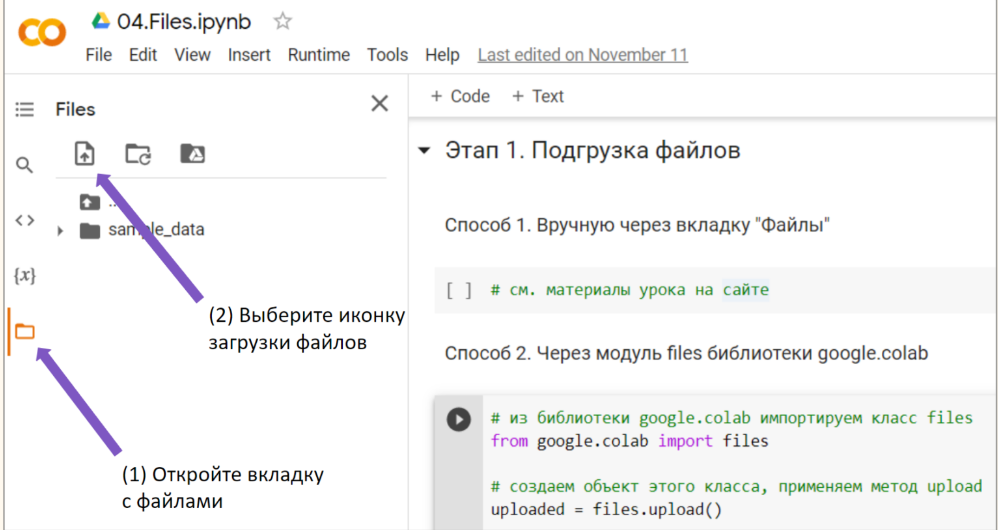
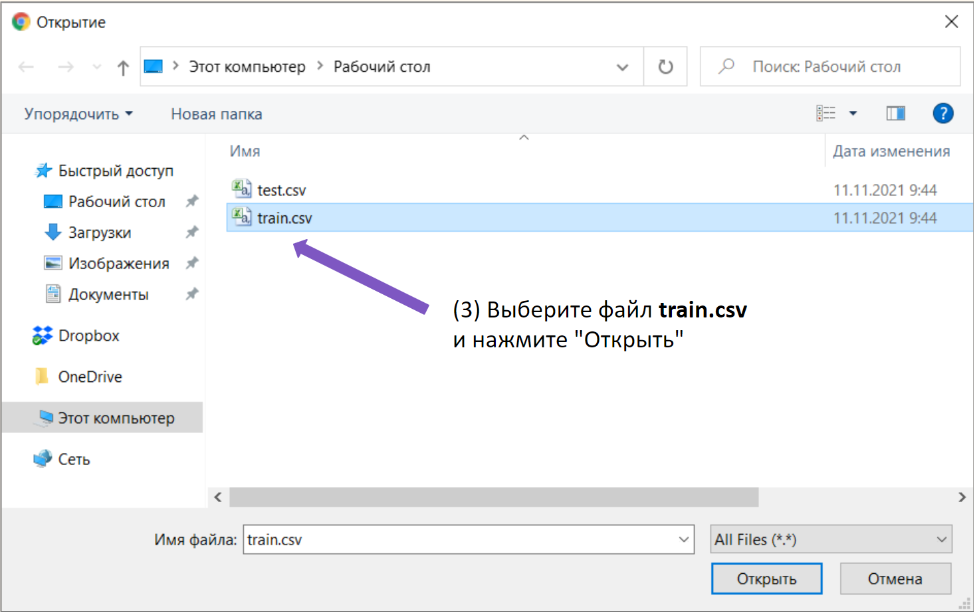

#### Способ 2. Через объект files библиотеки google.colab

In [28]:
# К объекту files мы применяем метод .upload(),
# который
# передает нам словарь. Ключами этого словаря
# будут
# названия файлов, а значениями — сами
# подгруженные
# данные. Приведем пример с файлом
# test.csv.
#
# # из библиотеки google.colab импортируем
# класс files
# from google.colab import files
#
# # создаем объект этого класса, применяем метод .upload()
# uploaded = files.upload()

### Этап 2. Чтение файлов
После загрузки оба файла (train.csv и test.csv) оказываются в
сессионном хранилище в папке под названием /content/.

### Просмотр содержимого в папке /content/

#### Модуль os и метод .walk()
Для того чтобы просмотреть ее содержимое внутри блокнота, мы
можем воспользоваться модулем os (отвечает за взаимодействие
Питона с операционной системой) и, в частности, методом .walk()
(позволяет «пройтись» по содержимому конкретной папки).

In [29]:
# # импортируем модуль os
import os

# выводим пути к папкам (dirpath) и наименования файлов (filenames) и
# после этого
for dirpath, _, filenames in os.walk("/content/"):

    # во вложенном цикле проходимся по названиям файлов
    for filename in filenames:

        # и соединяем путь до папок и входящие в эти папки файлы
        # с помощью метода path.join()
        print(os.path.join(dirpath, filename))

### Команда !ls
Кроме того, если нас интересуют только видимые файлы и папки,
мы можем воспользоваться командой !ls (ls означает to list, т.е. «перечислить»).

### Чтение из переменной uploaded

Основная особенность: информация в объекте bytes представляет
собой последовательность байтов (byte string), в то время как
обычная строка — это последовательность символов (character string).
Компьютер понимает первый тип, мы (люди) — второй.

In [30]:
# посмотрим на тип значений словаря uploaded
# type(uploaded['test.csv'])

In [31]:
# Таким образом, чтобы прочитать данные напрямую из
# словаря uploaded, вначале нам нужно преобразовать
# эти данные в обычную строку.

# обратимся к ключу словаря uploaded и применим
# метод .decode()
# uploaded_str = uploaded['test.csv'].decode()

# на выходе получаем обычную строку
# print(type(uploaded_str))

In [32]:
# Выведем первые 35 значений.

# print(uploaded_str[:35])

# Если разбить строку методом .split() по символам
# \r (возврат к началу строки) и \n (новая строка),
# то на выходе мы получим список.

# uploaded_list = uploaded_str.split('\r\n')
# type(uploaded_list)

# Пройдемся по этому списку и выведем первые четыре значения.

# не забудем создать индекс с помощью функции enumerate()
# for i, line in enumerate(uploaded_list):

# начнем выводить записи
#   print(line)

# когда дойдем до четвертой строки
#   if i == 3:

# прервемся
# break

### Использование функции open() и конструкции with open()
Такого же результата можно добиться с помощью базовой функции open().

Функция open() возвращает объект, который используется для чтения и изменения файла. Откроем файл train.csv.

In [33]:
# передадим функции open() адрес файла
# параметр 'r' означает, что мы хотим прочитать (read) файл
# f1 = open('/content/train.csv', 'r')

# Вначале попробуем применить метод .read().

# метод .read() помещает весь файл в одну строку
# выведем первые 142 символа (если параметр не указывать, выведется все содержимое)
# print(f1.read(142))

# в конце файл необходимо закрыть
# f1.close()

In [34]:
# Для наших целей метод .read() не очень удобен. Будет лучше пройтись по файлу в цикле for.

# снова откроем файл
# f2 = open('/content/train.csv', 'r')
#
# # пройдемся по нашему объекту в цикле for и параллельно создадим индекс
# for i, line in enumerate(f2):
#
#     # выведем строки без служебных символов по краям
#     print(line.strip())
#
#     # дойдя до четвертой строки, прервемся
#     if i == 3:
#       break
#
# # не забудем закрыть файл
# f2.close()

In [35]:
# Еще один способ — использовать конструкцию with open(). В этом случае специально закрывать файл не нужно.

# скажем Питону: "открой файл и назови его f3"
# with open("/content/test.csv") as f3:
#
#     # "пройдись по строкам без служебных символов"
#     for i, line in enumerate(f3):
#         print(line.strip())
#
#         # и "прервись на четвертой строке"
#         if i == 3:
#             break

### Чтение через библиотеку Pandas
Вероятно наиболее удобный и подходящий для наших целей способ чтения файлов — это
преобразование напрямую в датафрейм библиотеки Pandas. С этим методом в целом мы уже знакомы.

In [36]:
# импортируем библиотеку
# import pandas as pd
#
# # применим функцию read_csv() и посмотрим на первые три записи файла train.csv
# train = pd.read_csv('/content/train.csv')
# train.head(3)
#
# # сделаем то же самое с файлом test.csv
# test = pd.read_csv('/content/test.csv')
# test.head(3)